In [1]:
import os, yaml, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from II_analyses.metrics_comparison import metric_comparison_save_name


In [43]:
from dataclasses import dataclass

@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    new_fs: int = 100
    ks: tuple = (1, 10, 50, 100) #, 200) #, 500)
    metric_A: str = "cosine_cnt"
    metric_B: str = "correlation"
    results_dir: Path = Path(paths["data_path"]) / "results"
    subsamples_size=200
    iterations=20

cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', new_fs=100, ks=(1, 10, 50, 100), metric_A='cosine_cnt', metric_B='correlation', results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'))

In [44]:
def metric_comparison_fn(metric_from, metric_to, k):
    return Path(
        metric_comparison_save_name(
            paths,
            metric_from,
            metric_to,
            k,
            cfg.monkey_name,
            cfg.date,
            cfg.brain_area,
            cfg.new_fs,
            subsamples_size=cfg.subsamples_size,
            n_iterations=cfg.iterations
        )
    )

def load_metric_comparison(metric_from, metric_to, k):
    fn = metric_comparison_fn(metric_from, metric_to, k)
    if not fn.exists():
        raise FileNotFoundError(fn)
    return np.load(fn)["arr_0"]


A2B = {}
B2A = {}
missing = []
for k in cfg.ks:
    for metric_from, metric_to, target in [
        (cfg.metric_A, cfg.metric_B, A2B),
        (cfg.metric_B, cfg.metric_A, B2A),
    ]:
        try:
            target[k] = load_metric_comparison(metric_from, metric_to, k)
        except FileNotFoundError:
            missing.append(metric_comparison_fn(metric_from, metric_to, k))

if missing:
    for fn in missing:
        print(f"missing: {fn}")
    raise FileNotFoundError(f"Missing {len(missing)} metric-comparison files")

n_time = len(next(iter(A2B.values())))
time_bins = np.arange(n_time)
print(f"loaded {len(cfg.ks)} k values; timecourse length = {n_time}")


loaded 4 k values; timecourse length = 30


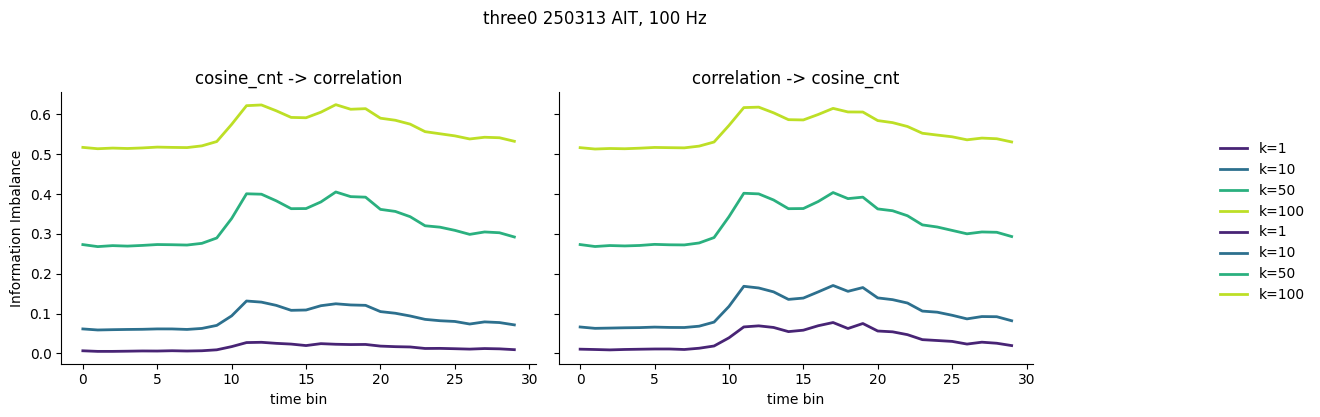

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(cfg.ks)))

for color, k in zip(colors, cfg.ks):
    ax[0].plot(time_bins, A2B[k], color=color, linewidth=2, label=f"k={k}")
    ax[1].plot(time_bins, B2A[k], color=color, linewidth=2, label=f"k={k}")

ax[0].set_title(f"{cfg.metric_A} -> {cfg.metric_B}")
ax[1].set_title(f"{cfg.metric_B} -> {cfg.metric_A}")
for a in ax:
    a.set_xlabel("time bin")
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_ylabel("Information Imbalance")

fig.suptitle(
    f"{cfg.monkey_name} {cfg.date} {cfg.brain_area}, {cfg.new_fs} Hz",
    y=1.03,
)
fig.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout(rect=[0, 0, 0.88, 1])


Text(0.5, 0.98, 'three0 250313 AIT, 100 Hz')

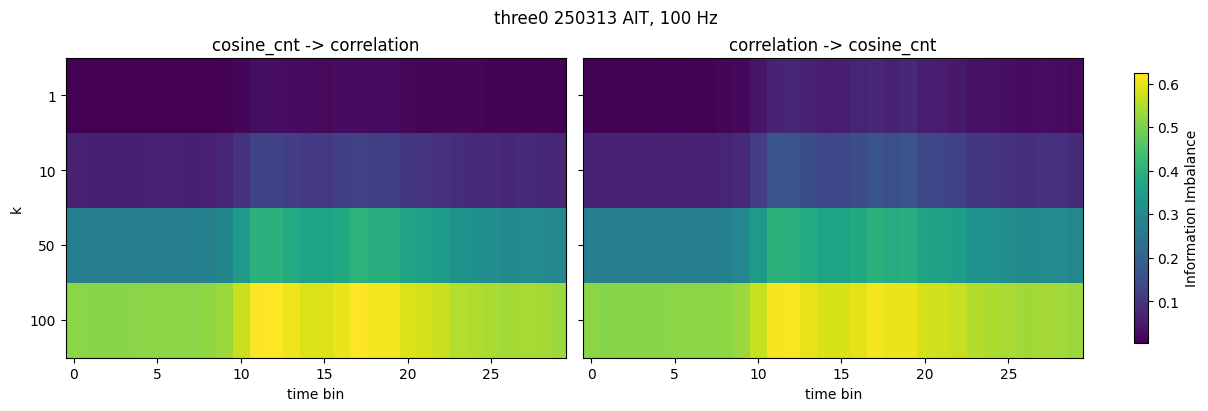

In [46]:
A2B_mat = np.stack([A2B[k] for k in cfg.ks])
B2A_mat = np.stack([B2A[k] for k in cfg.ks])
vmin = min(A2B_mat.min(), B2A_mat.min())
vmax = max(A2B_mat.max(), B2A_mat.max())

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)
for a, mat, title in [
    (ax[0], A2B_mat, f"{cfg.metric_A} -> {cfg.metric_B}"),
    (ax[1], B2A_mat, f"{cfg.metric_B} -> {cfg.metric_A}"),
]:
    im = a.imshow(mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    a.set_title(title)
    a.set_xlabel("time bin")
    a.set_yticks(np.arange(len(cfg.ks)))
    a.set_yticklabels(cfg.ks)
ax[0].set_ylabel("k")

fig.colorbar(im, ax=ax, label="Information Imbalance", shrink=0.9)
fig.suptitle(f"{cfg.monkey_name} {cfg.date} {cfg.brain_area}, {cfg.new_fs} Hz")
